# Exploratory Data Analysis (EDA)
Notebook này phân tích tập dữ liệu `Phishing_Email.csv` để chuẩn bị số liệu và biểu đồ cho Báo cáo Đồ án môn CS221.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import warnings
warnings.filterwarnings('ignore')

# Đặt kích thước và style biểu đồ mặc định
plt.rcParams['figure.figsize'] = (10, 6)
plt.style.use('ggplot')

# Tạo thư mục lưu báo cáo nếu chưa có
os.makedirs('../reports/eda', exist_ok=True)

# Thêm đường dẫn project vào sys.path để import được src
sys.path.append(os.path.abspath('..'))

## 1. Tải và xem dữ liệu cơ bản

In [2]:
# Load dữ liệu
df = pd.read_csv('../data/Phishing_Email.csv')
df = df.dropna(subset=['Email Text', 'Email Type'])
df['Email Text'] = df['Email Text'].astype(str)
print(f"Tổng số mẫu: {len(df)}")
df.head()

Tổng số mẫu: 18634


,Unnamed: 0,Email Text,Email Type
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,1,the other side of * galicismos * * galicismo *...,Safe Email
2,2,re : equistar deal tickets are you still avail...,Safe Email
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email


## 2. Phân bố nhãn (Class Distribution)
Mục đích: Phân tích xem dữ liệu có bị mất cân bằng (imbalanced data) hay không. Biểu đồ này cực kỳ cần thiết cho phần 2 của báo cáo đồ án.

Email Type
Safe Email        11322
Phishing Email     7312
Name: count, dtype: int64


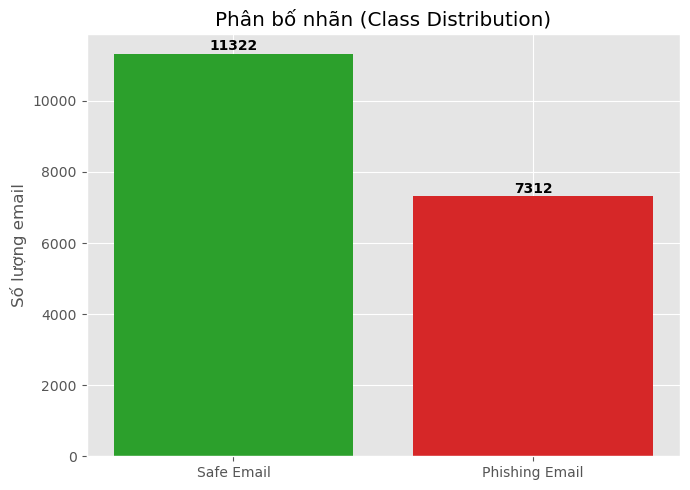

In [3]:
class_counts = df['Email Type'].value_counts()
print(class_counts)

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(class_counts.index, class_counts.values, color=['#2ca02c', '#d62728'])
ax.set_title('Phân bố nhãn (Class Distribution)')
ax.set_ylabel('Số lượng email')

for i, v in enumerate(class_counts.values):
    ax.text(i, v + 100, str(v), ha='center', fontweight='bold')

plt.tight_layout()
# Lưu biểu đồ ra file để bạn dễ chèn vào báo cáo Word
plt.savefig('../reports/eda/class_distribution.png', dpi=150)
plt.show()

## 3. Phân tích độ dài Email (Email Length)
Liệu Email lừa đảo thường dài hơn hay ngắn hơn Email an toàn?

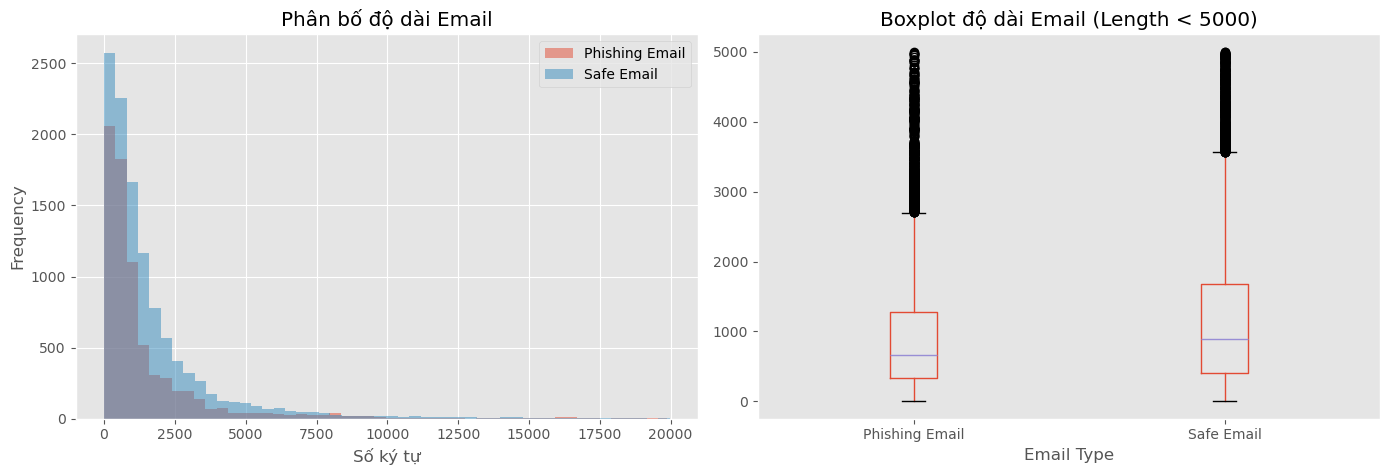

In [4]:
df['Length'] = df['Email Text'].apply(len)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogram (giới hạn length < 20000 để dễ nhìn, tránh các email rác quá dài làm hỏng biểu đồ)
df[df['Length'] < 20000].groupby('Email Type')['Length'].plot(kind='hist', bins=50, alpha=0.5, ax=ax1, legend=True)
ax1.set_title('Phân bố độ dài Email')
ax1.set_xlabel('Số ký tự')

# Boxplot để so sánh giá trị trung vị (median) và ngoại lệ (outliers)
df[df['Length'] < 5000].boxplot(column='Length', by='Email Type', ax=ax2, grid=False)
ax2.set_title('Boxplot độ dài Email (Length < 5000)')
plt.suptitle('')

plt.tight_layout()
plt.savefig('../reports/eda/email_length_distribution.png', dpi=150)
plt.show()

## 4. Phân tích các đặc trưng Heuristic (Heuristic Features)
Chúng ta sẽ vẽ biểu đồ chứng minh lý do tại sao ta lại chọn đếm số lượng URL, đếm dấu chấm than và tính tỷ lệ viết hoa.

,URL_Count,Uppercase_Ratio,Exclamation_Count
Email Type,,,
Phishing Email,0.289934,0.019143,3.296089
Safe Email,1.014838,0.014457,1.888006


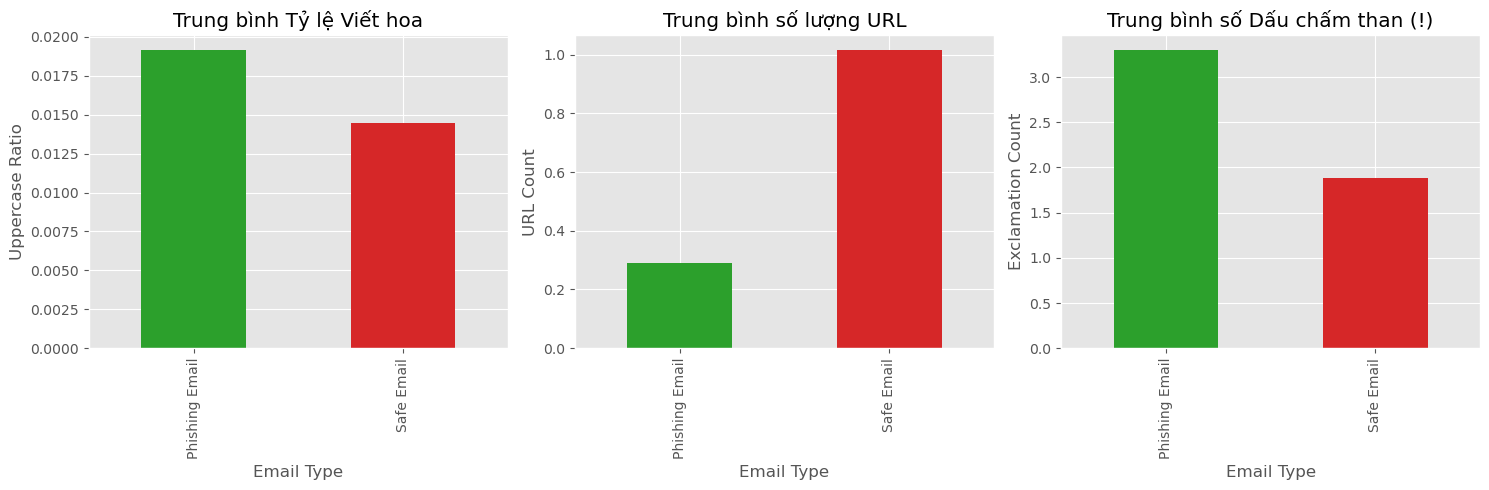

In [5]:
import re

URL_RE = re.compile(r"https?://\S+|www\.\S+", re.IGNORECASE)

df['URL_Count'] = df['Email Text'].apply(lambda t: len(URL_RE.findall(t)))
df['Uppercase_Ratio'] = df['Email Text'].apply(lambda t: sum(1 for c in t if c.isupper()) / max(len(t), 1))
df['Exclamation_Count'] = df['Email Text'].apply(lambda t: t.count('!'))

# Tính trung bình các đặc trưng theo nhóm để so sánh
heuristic_means = df.groupby('Email Type')[['URL_Count', 'Uppercase_Ratio', 'Exclamation_Count']].mean()
display(heuristic_means)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

df.groupby('Email Type')['Uppercase_Ratio'].mean().plot(kind='bar', ax=axes[0], color=['#2ca02c', '#d62728'])
axes[0].set_title('Trung bình Tỷ lệ Viết hoa')
axes[0].set_ylabel('Uppercase Ratio')

df.groupby('Email Type')['URL_Count'].mean().plot(kind='bar', ax=axes[1], color=['#2ca02c', '#d62728'])
axes[1].set_title('Trung bình số lượng URL')
axes[1].set_ylabel('URL Count')

df.groupby('Email Type')['Exclamation_Count'].mean().plot(kind='bar', ax=axes[2], color=['#2ca02c', '#d62728'])
axes[2].set_title('Trung bình số Dấu chấm than (!)')
axes[2].set_ylabel('Exclamation Count')

plt.tight_layout()
plt.savefig('../reports/eda/heuristic_features.png', dpi=150)
plt.show()

## 5. Phân tích từ vựng (Top Words)
Biểu đồ này sẽ chỉ ra những từ khóa xuất hiện nhiều nhất trong thư Phishing so với thư Safe.

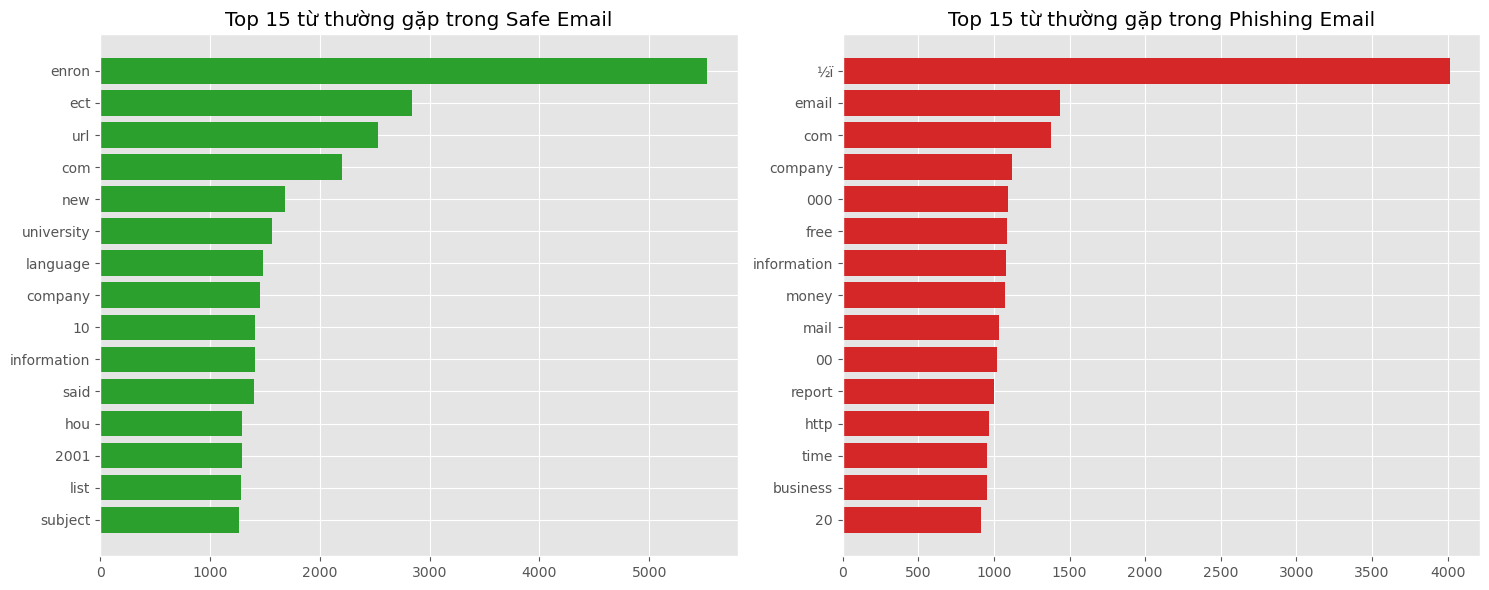

In [6]:
from sklearn.feature_extraction.text import CountVectorizer
from src.preprocess import clean_text

# Chỉ lấy sample 5000 mẫu ngẫu nhiên để phân tích cho nhanh (tiết kiệm RAM)
df_sample = df.sample(min(5000, len(df)), random_state=42).copy()
df_sample['Clean_Text'] = df_sample['Email Text'].apply(clean_text)

def get_top_n_words(corpus, n=15):
    # english stop_words loại bỏ các từ vô nghĩa như the, is, a, an...
    vec = CountVectorizer(stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

safe_texts = df_sample[df_sample['Email Type'] == 'Safe Email']['Clean_Text']
phishing_texts = df_sample[df_sample['Email Type'] == 'Phishing Email']['Clean_Text']

top_safe = get_top_n_words(safe_texts)
top_phishing = get_top_n_words(phishing_texts)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot Safe
words, freqs = zip(*top_safe)
ax1.barh(words, freqs, color='#2ca02c')
ax1.invert_yaxis() # Đảo ngược trục Y để từ xuất hiện nhiều nhất nằm ở trên cùng
ax1.set_title('Top 15 từ thường gặp trong Safe Email')

# Plot Phishing
words, freqs = zip(*top_phishing)
ax2.barh(words, freqs, color='#d62728')
ax2.invert_yaxis()
ax2.set_title('Top 15 từ thường gặp trong Phishing Email')

plt.tight_layout()
plt.savefig('../reports/eda/top_words.png', dpi=150)
plt.show()